Generating ground truth trajectories...
Successfully generated 120 valid trajectories.
Rejected 14 short trajectories during generation.
Created 7616 test samples from 120 trajectories
Model and weights loaded successfully!

Starting inference on 7616 chains...


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_9139/4202545676.py:140: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_input_sequence = torch.tensor(test_input, dtype=torch.float32)


Progress: 100/7616 chains (1.3%) | Speed: 87.9 chains/s | ETA: 85.5s
Progress: 200/7616 chains (2.6%) | Speed: 86.7 chains/s | ETA: 85.5s
Progress: 300/7616 chains (3.9%) | Speed: 87.8 chains/s | ETA: 83.3s
Progress: 400/7616 chains (5.3%) | Speed: 88.6 chains/s | ETA: 81.5s
Progress: 500/7616 chains (6.6%) | Speed: 89.1 chains/s | ETA: 79.9s
Progress: 600/7616 chains (7.9%) | Speed: 89.2 chains/s | ETA: 78.7s
Progress: 700/7616 chains (9.2%) | Speed: 89.4 chains/s | ETA: 77.4s
Progress: 800/7616 chains (10.5%) | Speed: 89.3 chains/s | ETA: 76.3s
Progress: 900/7616 chains (11.8%) | Speed: 89.3 chains/s | ETA: 75.2s
Progress: 1000/7616 chains (13.1%) | Speed: 89.3 chains/s | ETA: 74.1s
Progress: 1100/7616 chains (14.4%) | Speed: 89.2 chains/s | ETA: 73.0s
Progress: 1200/7616 chains (15.8%) | Speed: 89.0 chains/s | ETA: 72.1s
Progress: 1300/7616 chains (17.1%) | Speed: 88.9 chains/s | ETA: 71.0s
Progress: 1400/7616 chains (18.4%) | Speed: 88.9 chains/s | ETA: 69.9s
Progress: 1500/7616 ch

KeyboardInterrupt: 

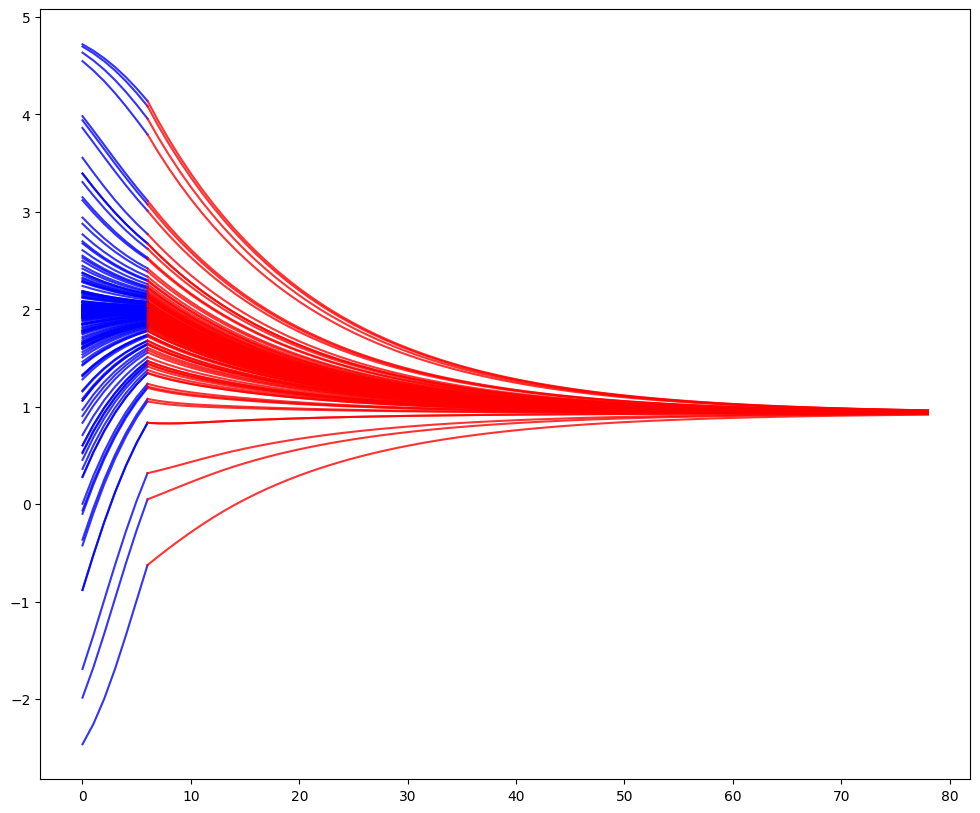

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.polynomial import Polynomial
import torch
import torch.nn as nn
import math
from torch.nn import functional as F
import time

# ========== Generate Ground Truth Data ==========
# f(x) = x^3 - 4x^2 - 11x + 30
# System has 3 equilibria at [-3, 2, 5]. -3 and 5 are unstable, 2 is stable
coeffs = [30, -11, -4, 1]
poly = Polynomial(coeffs)

def f(x):
    return poly(x)

def polyDyn1d(t, y):
    return f(y)

t_span = (0, 0.8)
t_eval = np.linspace(*t_span, 80)
x0_min, x0_max = -6.0, 6.0
n_trajectories_target = 120
min_length = 7

solutions = []
all_trajectories = []
rejected_count = 0

print("Generating ground truth trajectories...")
while len(all_trajectories) < n_trajectories_target:
    x0 = np.random.uniform(-4.0, 6.0)
    solution = solve_ivp(polyDyn1d, t_span, [x0], t_eval=t_eval)
    if len(solution.y[0]) >= min_length:
        all_trajectories.append(solution.y[0])
        solutions.append(solution)
    else:
        rejected_count += 1
        
print(f"Successfully generated {len(all_trajectories)} valid trajectories.")
print(f"Rejected {rejected_count} short trajectories during generation.")

#========== Create Test Dataset ==========
block_size = 7

test_inputs = []
test_targets = []

for i in range(len(all_trajectories)):
    trajectory = all_trajectories[i]
    for j in range(len(trajectory) - block_size):
        test_inputs.append(trajectory[j:j+block_size])
        test_targets.append(trajectory[j+block_size])

test_inputs = np.array(test_inputs)
test_targets = np.array(test_targets)

print(f"Created {len(test_inputs)} test samples from {len(all_trajectories)} trajectories")


# ========== Model Hyperparameters (must match training) ==========
n_embd = 5
num_heads = 1
head_size = n_embd // num_heads
dropout_rate = 0.2

# ========== Load Checkpoint ==========
checkpoint = torch.load('1d_transformer.pt', weights_only=False)

# ========== Recreate Model Architecture ==========
embed = nn.Linear(1, n_embd, bias=False)
w_key = nn.Linear(n_embd, head_size, bias=False)
w_query = nn.Linear(n_embd, head_size, bias=False)
w_value = nn.Linear(n_embd, head_size, bias=False)
w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
dropout = nn.Dropout(dropout_rate)
norm_attn_gain = nn.Parameter(torch.ones(n_embd))
norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
w_ffn = nn.Linear(n_embd, 4 * n_embd)
w_ffn_output = nn.Linear(4 * n_embd, n_embd)
norm_logits_gain = nn.Parameter(torch.ones(n_embd))
norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
w_logits_output = nn.Linear(n_embd, 1)

# ========== Load Trained Weights ==========
embed.weight.data = checkpoint['embed_weight']
w_key.weight.data = checkpoint['w_key_weight']
w_query.weight.data = checkpoint['w_query_weight']
w_value.weight.data = checkpoint['w_value_weight']
w_attn_output.weight.data = checkpoint['w_attn_output_weight']
norm_attn_gain.data = checkpoint['norm_attn_gain']
norm_attn_bias.data = checkpoint['norm_attn_bias']
w_ffn.weight.data = checkpoint['w_ffn_weight']
w_ffn.bias.data = checkpoint['w_ffn_bias']
w_ffn_output.weight.data = checkpoint['w_ffn_output_weight']
w_ffn_output.bias.data = checkpoint['w_ffn_output_bias']
norm_logits_gain.data = checkpoint['norm_logits_gain']
norm_logits_bias.data = checkpoint['norm_logits_bias']
w_logits_output.weight.data = checkpoint['w_logits_output_weight']
w_logits_output.bias.data = checkpoint['w_logits_output_bias']

print("Model and weights loaded successfully!")

# ========== Set Model to Evaluation Mode ==========
embed.eval()
dropout.eval()

# ========== Run Inference ==========
indices = np.random.permutation(len(test_inputs))
shuffled_test_inputs = [test_inputs[i] for i in indices]

chains = []
print(f"\nStarting inference on {len(shuffled_test_inputs)} chains...")
print("=" * 60)
start_time = time.time()

with torch.no_grad():
    j = 0
    for idx, test_input in enumerate(shuffled_test_inputs):
        # Print progress every 100 chains
        if (idx + 1) % 100 == 0:
            elapsed = time.time() - start_time
            chains_per_sec = (idx + 1) / elapsed
            remaining = (len(shuffled_test_inputs) - idx - 1) / chains_per_sec
            print(f"Progress: {idx + 1}/{len(shuffled_test_inputs)} chains "
                  f"({100 * (idx + 1) / len(shuffled_test_inputs):.1f}%) | "
                  f"Speed: {chains_per_sec:.1f} chains/s | "
                  f"ETA: {remaining:.1f}s")
        
        chain = test_input.tolist()
        chains.append(chain)
        cancel = False
        i = block_size + 1
        prediction = 0
        
        while i < 80 and cancel == False:
            test_input_sequence = torch.tensor(test_input, dtype=torch.float32)
            test_input_data = test_input_sequence[:block_size]
            test_input_data = test_input_data.unsqueeze(-1)
            test_target = test_input_sequence[-1]
            
            # Forward pass
            test_embedded_input = embed(test_input_data)
            K, Q, V = w_key(test_embedded_input), w_query(test_embedded_input), w_value(test_embedded_input)
            raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(head_size))
            attention_probabilities = F.softmax(raw_attention_scores, dim=-1)
            attention_output = w_attn_output(attention_probabilities @ V)
            
            FFN_in_raw = attention_output + test_embedded_input
            FFN_in_normalized = norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + norm_attn_bias
            
            FFN_activations = F.relu(w_ffn(FFN_in_normalized))
            FFN_output = w_ffn_output(FFN_activations)
            
            logits_raw = FFN_output + FFN_in_normalized
            logits_normalized = norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + norm_logits_bias
            
            logits = w_logits_output(logits_normalized)
            prediction = logits[-1, 0].item()
            
            # Update chain
            chain = chain[1:]
            chain.append(prediction)
            chains[j].append(prediction)
            test_input = torch.tensor(chain[-block_size:], dtype=torch.float32)
            i += 1
                
            if prediction < -5 or prediction > 7.5:
                cancel = True
        j += 1

total_time = time.time() - start_time
print("=" * 60)
print(f"Inference complete! Generated {len(chains)} chains in {total_time:.2f}s")
print(f"Average speed: {len(chains) / total_time:.2f} chains/s")

# ========== Visualize Results ==========
fig, ax1 = plt.subplots(1, figsize=(12, 10))
for chain in chains:
    t = np.arange(len(chain))
    ax1.plot(t[:block_size], chain[:block_size], color='blue', alpha=0.8)
    ax1.plot(t[block_size-1:], chain[block_size-1:], color='red', alpha=0.8)

ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_title(f"Neural Network Generated Chains ({len(chains)} Trajectories)")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Value")
ax1.grid()
ax1.set_ylim(-5, 7.5)
plt.tight_layout()
plt.show()

In [ ]:
import random
import numpy as np
from sklearn import linear_model as lm
import copy
import matplotlib.pyplot as plt

dimension_5_total = 0
total_dimensions = 0
def single_inference_point(test_input):
    test_input_sequence = torch.tensor(test_input, dtype=torch.float32)
    test_input_data = test_input_sequence[:block_size]
    test_input_data = test_input_data.unsqueeze(-1)

    # Forward pass
    test_embedded_input = embed(test_input_data)
    K, Q, V = w_key(test_embedded_input), w_query(test_embedded_input), w_value(test_embedded_input)
    raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(head_size))
    attention_probabilities = F.softmax(raw_attention_scores, dim=-1)
    attention_output = w_attn_output(attention_probabilities @ V)

    FFN_in_raw = attention_output + test_embedded_input
    FFN_in_normalized = norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + norm_attn_bias

    FFN_activations = F.relu(w_ffn(FFN_in_normalized))
    FFN_output = w_ffn_output(FFN_activations)

    logits_raw = FFN_output + FFN_in_normalized
    logits_normalized = norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + norm_logits_bias

    logits = w_logits_output(logits_normalized)
    prediction = logits[-1, 0].item()
    return prediction

def get_data(box, train_point_num, test_point_num):
    points_x = []
    points_y = []
    for i in range(train_point_num + test_point_num):
        point = []
        for j in range(block_size - 1):
            x0 = random.uniform(box[j][0], box[j][1])
            point.append(x0)
        points_x.append(point)
        points_y.append(single_inference_point(point))

    return points_x[:train_point_num], points_y[:train_point_num], points_x[test_point_num:], points_y[test_point_num:]

def train_test_model(train_points_x, train_points_y, test_points_x, test_points_y):
    my_model = lm.LinearRegression()
    my_model.fit(train_points_x, train_points_y)
    max_error = 0
    for i, test_point_x in enumerate(test_points_x):
        predicted_y = my_model.predict([test_point_x])
        error = abs(predicted_y[0] - test_points_y[i])
        if error > max_error:
            max_error = error
    return max_error, my_model
    

def choose_split(box, train_point_num, test_point_num):
    min_error = np.inf
    best_box_model_pairs = []
    best_dimension = -1
    for dimension in range(len(box)):
        min_range, max_range = box[dimension]
        divider = (min_range + max_range) / 2
        box1 = copy.deepcopy(box)
        box1[dimension] = [divider, max_range]
        box2 = copy.deepcopy(box)
        box2[dimension] = [min_range, divider]
        train_points_x1, train_points_y1, test_points_x1, test_points_y1 = get_data(box1, train_point_num, test_point_num)
        error1, model1 = train_test_model(train_points_x1, train_points_y1, test_points_x1, test_points_y1)
        train_points_x2, train_points_y2, test_points_x2, test_points_y2 = get_data(box2, train_point_num, test_point_num)
        error2, model2 = train_test_model(train_points_x2, train_points_y2, test_points_x2, test_points_y2)
        if error1 + error2 < min_error:
            min_error = error1 + error2
            best_box_model_pairs = [{"box": box1, "model": model1}, {"box": box2, "model": model2}]
            best_dimension = dimension
    print(f"Chose to split dimension {best_dimension} with combined error {min_error}")
    return best_box_model_pairs

def split_box(box):
    train_points_x, train_points_y, test_points_x, test_points_y = get_data(box, train_point_num, test_point_num)
    error, model = train_test_model(train_points_x, train_points_y, test_points_x, test_points_y)
    if error < epsilon:
        print(f"Box found with error: {error}")
        return [{"box": box, "model": model}]
    else:
        box_model_pairs = choose_split(box, train_point_num, test_point_num)
        return split_box(box_model_pairs[0]["box"]) + split_box(box_model_pairs[1]["box"])


test_point_num = 100
train_point_num = 50
epsilon = 0.1
block_size = 7
box = np.tile([-3, 3], (block_size - 1, 1)).tolist()
box_model_pairs = split_box(box)
print(f"Generated {len(box_model_pairs)} boxes with models")

Chose to split dimension 5 with combined error 0.5562026173693123
Box found with error: 0.015301049498372521
Chose to split dimension 5 with combined error 0.45824861387636445
Chose to split dimension 5 with combined error 0.17609499171134996
Box found with error: 0.03883753330618942
Chose to split dimension 5 with combined error 0.21888654691970422
Chose to split dimension 5 with combined error 0.14514543554521664
Box found with error: 0.06565499508923323
Box found with error: 0.08178058811945332
Chose to split dimension 1 with combined error 0.21931158553448427
Chose to split dimension 3 with combined error 0.15976343394061754
Box found with error: 0.09891578194614237
Box found with error: 0.0925862257130825
Chose to split dimension 1 with combined error 0.21745449692559093
Box found with error: 0.0939979679410865
Chose to split dimension 5 with combined error 0.22394659006308837
Chose to split dimension 5 with combined error 0.19375821780012092
Box found with error: 0.08182439865598

OVERLAP ANALYSIS

Total number of boxes: 62
Number of overlapping pairs: 0

✓ SUCCESS: No overlapping boxes found!

COVERAGE STATISTICS

Initial domain volume: 46656.000000
Total volume of all boxes: 46656.000000
Coverage ratio: 1.0000

DIMENSION COVERAGE

Dimension 0:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 1:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 2:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 3:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 4:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 5:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_81169/3616894666.py:126: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle(center, radius, alpha=0.3, color='blue', edgecolor='black', linewidth=0.5)


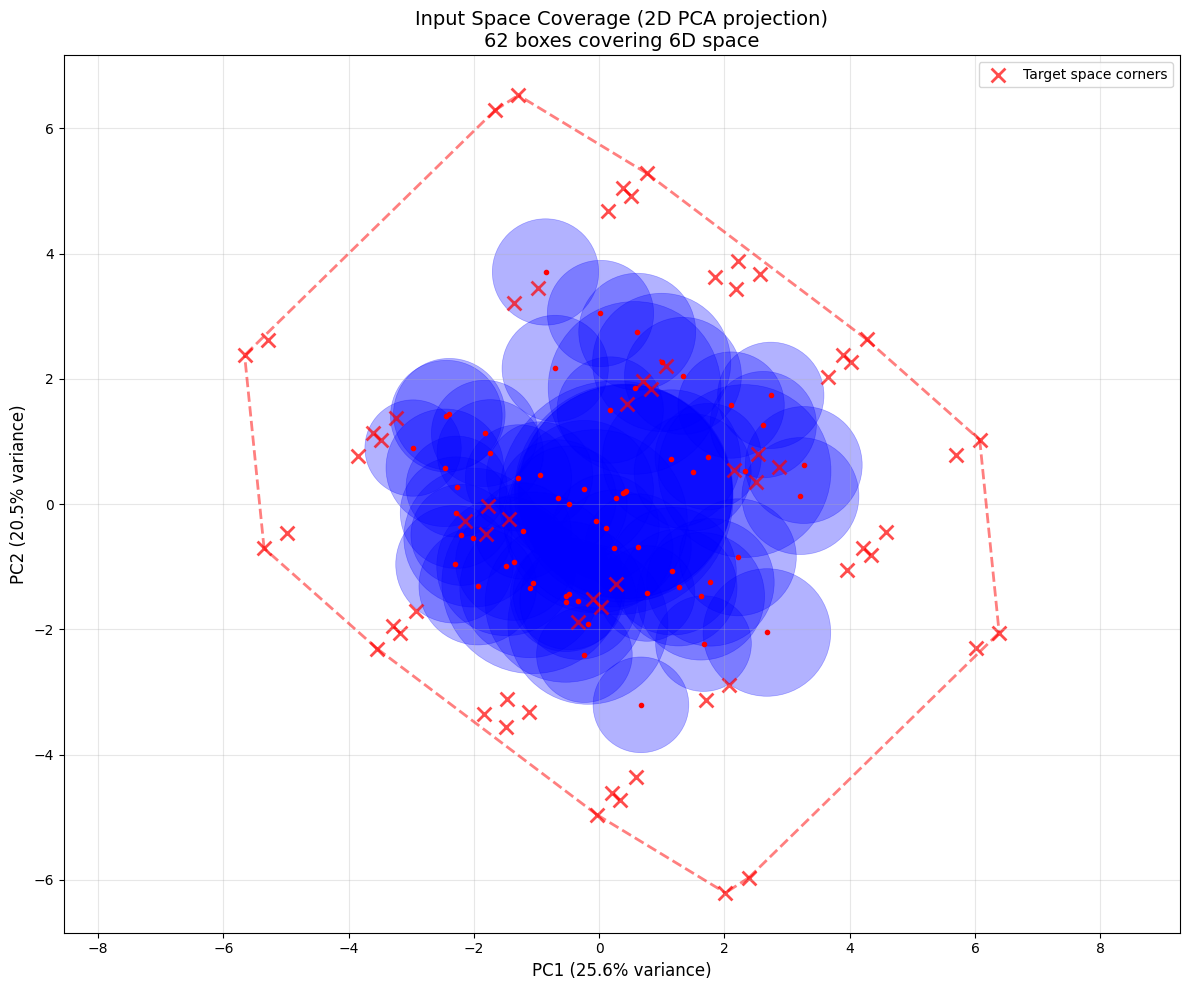


Total variance explained by 2D projection: 46.1%
Number of boxes: 62
Dimensions: 6

PCA Component 1 weights:
  Dimension 0: 0.052
  Dimension 1: 0.666
  Dimension 2: 0.301
  Dimension 3: -0.585
  Dimension 4: 0.342
  Dimension 5: -0.062

PCA Component 2 weights:
  Dimension 0: -0.514
  Dimension 1: 0.652
  Dimension 2: -0.267
  Dimension 3: 0.442
  Dimension 4: -0.208
  Dimension 5: -0.040


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_81169/3616894666.py:185: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((center_j - size_j, center_i - size_i),


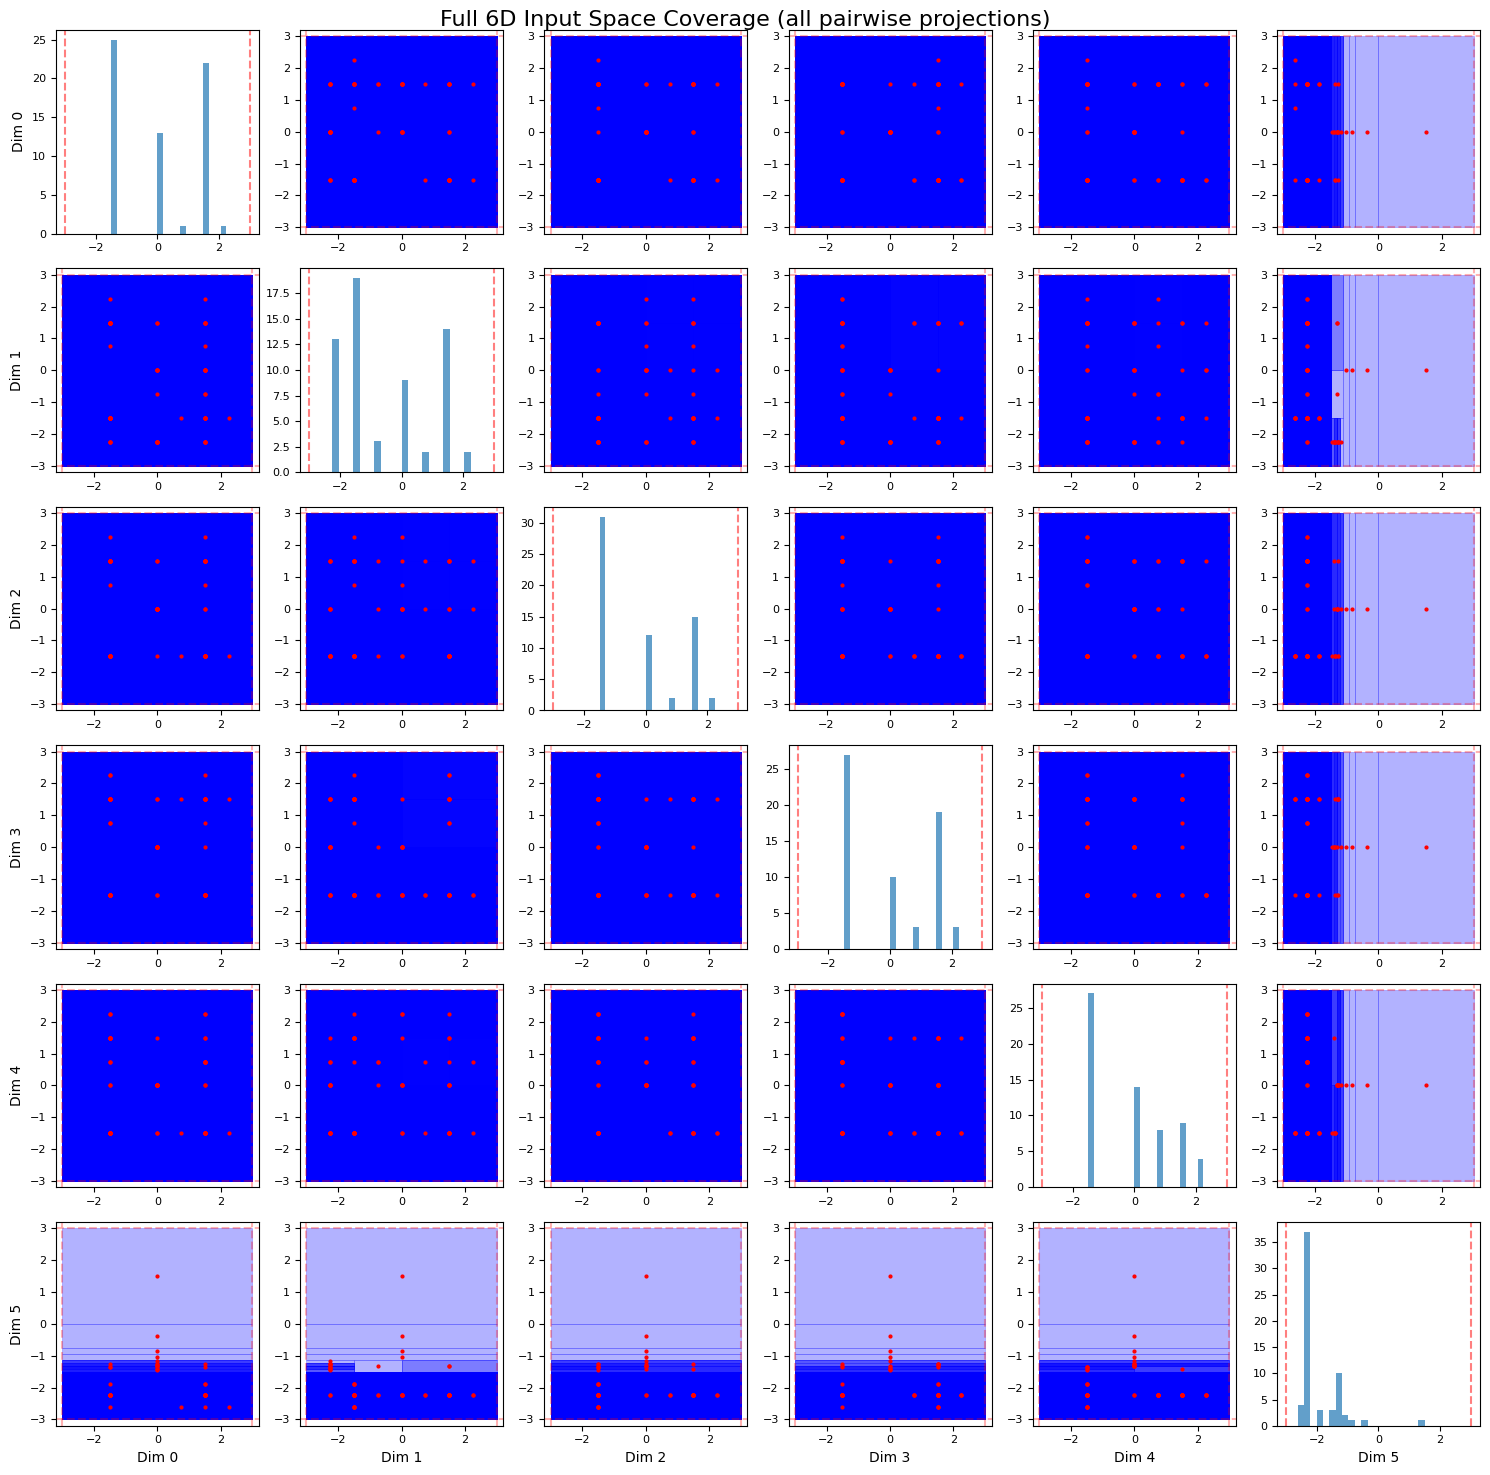

In [ ]:
boxes = [pair["box"] for pair in box_model_pairs]
range_to_cover = [-3, 3]

def boxes_overlap(box1, box2):
    for dim in range(len(box1)):
        min1, max1 = box1[dim]
        min2, max2 = box2[dim]
        if max1 <= min2 or max2 <= min1:
            return False
    return True

def check_all_overlaps(boxes):
    overlapping_pairs = []
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            if boxes_overlap(boxes[i], boxes[j]):
                overlapping_pairs.append((i, j))
    
    return overlapping_pairs

def calculate_overlap_volume(box1, box2):
    if not boxes_overlap(box1, box2):
        return 0.0
    
    overlap_volume = 1.0
    for dim in range(len(box1)):
        min1, max1 = box1[dim]
        min2, max2 = box2[dim]
        overlap_min = max(min1, min2)
        overlap_max = min(max1, max2)
        overlap_length = overlap_max - overlap_min
        
        overlap_volume *= overlap_length
    
    return overlap_volume

def calculate_box_volume(box):
    volume = 1.0
    for dim_range in box:
        volume *= (dim_range[1] - dim_range[0])
    return volume

print("=" * 60)
print("OVERLAP ANALYSIS")
print("=" * 60)

overlapping_pairs = check_all_overlaps(boxes)

print(f"\nTotal number of boxes: {len(boxes)}")
print(f"Number of overlapping pairs: {len(overlapping_pairs)}")

if len(overlapping_pairs) == 0:
    print("\n✓ SUCCESS: No overlapping boxes found!")
else:
    print(f"\n✗ WARNING: Found {len(overlapping_pairs)} overlapping pairs")

    print("\nFirst 5 overlapping pairs (if any):")
    for idx, (i, j) in enumerate(overlapping_pairs[:5]):
        overlap_vol = calculate_overlap_volume(boxes[i], boxes[j])
        vol_i = calculate_box_volume(boxes[i])
        vol_j = calculate_box_volume(boxes[j])
        print(f"\nPair {idx + 1}: Box {i} and Box {j}")
        print(f"  Overlap volume: {overlap_vol:.6f}")
        print(f"  Box {i} volume: {vol_i:.6f}")
        print(f"  Box {j} volume: {vol_j:.6f}")
        print(f"  Overlap as % of box {i}: {100 * overlap_vol / vol_i:.2f}%")
        print(f"  Overlap as % of box {j}: {100 * overlap_vol / vol_j:.2f}%")

print("\n" + "=" * 60)
print("COVERAGE STATISTICS")
print("=" * 60)

total_volume = sum(calculate_box_volume(box) for box in boxes)
initial_volume = calculate_box_volume([[-3, 3]] * (block_size - 1))

print(f"\nInitial domain volume: {initial_volume:.6f}")
print(f"Total volume of all boxes: {total_volume:.6f}")
print(f"Coverage ratio: {total_volume / initial_volume:.4f}")

if len(overlapping_pairs) > 0:
    total_overlap = sum(calculate_overlap_volume(boxes[i], boxes[j]) 
                       for i, j in overlapping_pairs)
    print(f"Total overlap volume: {total_overlap:.6f}")
    print(f"Overlap as % of total: {100 * total_overlap / total_volume:.2f}%")

print("\n" + "=" * 60)
print("DIMENSION COVERAGE")
print("=" * 60)

for dim in range(block_size - 1):
    dim_mins = [box[dim][0] for box in boxes]
    dim_maxs = [box[dim][1] for box in boxes]
    
    coverage_min = min(dim_mins)
    coverage_max = max(dim_maxs)
    
    print(f"\nDimension {dim}:")
    print(f"  Target range: [{range_to_cover[0]}, {range_to_cover[1]}]")
    print(f"  Actual coverage: [{coverage_min:.4f}, {coverage_max:.4f}]")
    
    if coverage_min > range_to_cover[0]:
        print(f"  ⚠ Gap at lower end: {coverage_min - range_to_cover[0]:.4f}")
    if coverage_max < range_to_cover[1]:
        print(f"  ⚠ Gap at upper end: {range_to_cover[1] - coverage_max:.4f}")
    if coverage_min <= range_to_cover[0] and coverage_max >= range_to_cover[1]:
        print(f"  ✓ Full coverage achieved")

from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

box_centers = np.array([[(box[dim][0] + box[dim][1]) / 2 for dim in range(len(box))] 
                        for box in boxes])
box_sizes = np.array([[(box[dim][1] - box[dim][0]) / 2 for dim in range(len(box))] 
                      for box in boxes])


pca = PCA(n_components=2)
centers_2d = pca.fit_transform(box_centers)

plt.figure(figsize=(12, 10))

for i, (center, box_size) in enumerate(zip(centers_2d, box_sizes)):
    avg_size = np.mean(box_size)
    radius = avg_size * np.sqrt(np.sum(pca.explained_variance_ratio_))
    
    circle = plt.Circle(center, radius, alpha=0.3, color='blue', edgecolor='black', linewidth=0.5)
    plt.gca().add_patch(circle)
    plt.plot(center[0], center[1], 'ro', markersize=3)

n_dims = len(boxes[0])
corner_points = []
for i in range(2**n_dims):
    corner = [range_to_cover[0] if (i >> j) & 1 == 0 else range_to_cover[1] 
              for j in range(n_dims)]
    corner_points.append(corner)
corners_2d = pca.transform(corner_points)

try:
    hull = ConvexHull(corners_2d)
    for simplex in hull.simplices:
        plt.plot(corners_2d[simplex, 0], corners_2d[simplex, 1], 'r--', alpha=0.5, linewidth=2)
except:
    pass

plt.scatter(corners_2d[:, 0], corners_2d[:, 1], c='red', marker='x', s=100, 
            label='Target space corners', alpha=0.7, linewidths=2)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'Input Space Coverage (2D PCA projection)\n{len(boxes)} boxes covering {n_dims}D space', fontsize=14)
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by 2D projection: {sum(pca.explained_variance_ratio_):.1%}")
print(f"Number of boxes: {len(boxes)}")
print(f"Dimensions: {n_dims}")

print("\nPCA Component 1 weights:")
for i, weight in enumerate(pca.components_[0]):
    print(f"  Dimension {i}: {weight:.3f}")
print("\nPCA Component 2 weights:")
for i, weight in enumerate(pca.components_[1]):
    print(f"  Dimension {i}: {weight:.3f}")

fig, axes = plt.subplots(6, 6, figsize=(15, 15))

for i in range(6):
    for j in range(6):
        ax = axes[i, j]
        if i == j:
            midpoints = [(box[i][0] + box[i][1]) / 2 for box in boxes]
            ax.hist(midpoints, bins=20, alpha=0.7)
            ax.axvline(range_to_cover[0], color='red', linestyle='--', alpha=0.5)
            ax.axvline(range_to_cover[1], color='red', linestyle='--', alpha=0.5)
        else:
            for box in boxes:
                center_i = (box[i][0] + box[i][1]) / 2
                center_j = (box[j][0] + box[j][1]) / 2
                size_i = (box[i][1] - box[i][0]) / 2
                size_j = (box[j][1] - box[j][0]) / 2
                
                rect = plt.Rectangle((center_j - size_j, center_i - size_i), 
                                    2 * size_j, 2 * size_i, 
                                    alpha=0.3, color='blue', edgecolor='black', linewidth=0.5)
                ax.add_patch(rect)
                ax.plot(center_j, center_i, 'ro', markersize=2)
            

            ax.axhline(range_to_cover[0], color='red', linestyle='--', alpha=0.3)
            ax.axhline(range_to_cover[1], color='red', linestyle='--', alpha=0.3)
            ax.axvline(range_to_cover[0], color='red', linestyle='--', alpha=0.3)
            ax.axvline(range_to_cover[1], color='red', linestyle='--', alpha=0.3)

            ax.set_xlim(range_to_cover[0] - 0.2, range_to_cover[1] + 0.2)
            ax.set_ylim(range_to_cover[0] - 0.2, range_to_cover[1] + 0.2)
            
        if j == 0:
            ax.set_ylabel(f'Dim {i}', fontsize=10)
        if i == 5:
            ax.set_xlabel(f'Dim {j}', fontsize=10)
        
        ax.tick_params(labelsize=8)

plt.suptitle('Full 6D Input Space Coverage (all pairwise projections)', fontsize=16)
plt.tight_layout()
plt.show()

# Probability Metrics For Each Box

# MILP Solving

In [ ]:
# Define decision variables
import gurobipy as gp
from gurobipy import GRB


m = gp.Model("Piecewise_Linear_Optimization")
# Define x as a 6d point in range
x = m.addVars(block_size - 1, lb=range_to_cover[0], ub=range_to_cover[1], name="x", vtype=GRB.CONTINUOUS)
# Define y as the output variable to minimize
y = m.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, name="y", vtype=GRB.CONTINUOUS)
# z: Binary variables (The "Switch"). z[i] = 1 if we are in region i
z = m.addVars(len(box_model_pairs), vtype=GRB.BINARY, name="z")


# The sum of all binary switches must be exactly 1.
m.addConstr(z.sum() == 1, name="OneRegionActive")
# Loop over boxes to add constraints
for i, pair in enumerate(box_model_pairs):
    box = pair["box"]
    model = pair["model"]
    # A. GEOMETRY: Constrain x to be inside Box i IF z[i] is active
    for dimension in range(block_size - 1):
        min_range, max_range = box[dimension]
        # If z[i] == 1, then x[dim] >= lb
        m.addGenConstrIndicator(z[i], True, x[dim] >= min_range)
        # If z[i] == 1, then x[dim] <= ub
        m.addGenConstrIndicator(z[i], True, x[dim] <= max_range)

    coeffs, intercept = model.coef_, model.intercept_
    # Create Model (need to use Gurobi bc x doesn't have a value right now)
    linear_pred = intercept + gp.quicksum(coeffs[j] * x[j] for j in range(block_size - 1))
    # If z[i] == 1, then y >= prediction - epsilon
    m.addGenConstrIndicator(z[i], True, y >= linear_pred - epsilon)
    # If z[i] == 1, then y <= prediction + epsilon
    m.addGenConstrIndicator(z[i], True, y <= linear_pred + epsilon)

print("--- Solving for Minimum ---")
m.setObjective(y, GRB.MINIMIZE)
m.optimize()

if m.status == GRB.OPTIMAL:
    min_y = y.X
    best_x = [x[k].X for k in range(block_size - 1)]
    active_region = [k for k in range(len(box_model_pairs)) if z[k].X > 0.5][0]
    print(f"Found Global Min y: {min_y:.4f}")
    print(f"Location x: {best_x}")
    print(f"Active Region Index: {active_region}")
else:
    print("Optimization failed or infeasible")

# 6. Solve for Maximum y (Reuse the same model!)
print("\n--- Solving for Maximum ---")
m.setObjective(y, GRB.MAXIMIZE)
m.optimize()

if m.status == GRB.OPTIMAL:
    max_y = y.X
    best_x = [x[k].X for k in range(block_size - 1)]
    active_region = [k for k in range(len(box_model_pairs)) if z[k].X > 0.5][0]
    print(f"Found Global Max y: {max_y:.4f}")
    print(f"Location x: {best_x}")
    print(f"Active Region Index: {active_region}")
else:
    print("Optimization failed or infeasible")

Set parameter Username
Set parameter LicenseID to value 2620375
Academic license - for non-commercial use only - expires 2026-02-10
--- Solving for Minimum ---
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M2 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 1 rows, 69 columns and 62 nonzeros
Model fingerprint: 0xe7f9e848
Model has 868 simple general constraints
  868 INDICATOR
Variable types: 7 continuous, 62 integer (62 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 3e+00]
  RHS range        [1e+00, 1e+00]
  GenCon rhs range [2e-02, 3e+00]
  GenCon coe range [6e-05, 2e+00]
Presolve added 16 rows and 0 columns
Presolve removed 0 rows and 41 columns
Presolve time: 0.01s
Presolved: 17 rows, 28 columns, 133 nonzeros
Presolved model has 14 SOS constraint(s)
Variable types: 21 continuous, 7 integer (7

In [ ]:
def check_property(box_model_pairs, input_range, objective_expr_type="value"):
    model = gp.Model("Verifier")
    total_dimensions = len(box_model_pairs[0]["box"])
    
    input_variables = model.addVars(
        total_dimensions,
        lb=input_range[0],
        ub=input_range[1],
        vtype=GRB.CONTINUOUS
    )
    output_variables = model.addVar(
        lb=-GRB.INFINITY,
        ub=GRB.INFINITY,
        vtype=GRB.CONTINUOUS
    )
    
    # You can only pick one region to cause out of bounds error
    switch_variables = model.addVars(len(box_model_pairs), vtype=GRB.BINARY)
    model.addConstr(switch_variables.sum() == 1)
    
    # Constraints
    for i, pair in enumerate(box_model_pairs):
        box = pair["box"]
        linear_model = pair["model"]
        
        # Input var must be inside current box
        for dim in range(total_dimensions):
            model.addGenConstrIndicator(
                switch_variables[i], True, input_variables[dim] >= box[dim][0]
            )
            model.addGenConstrIndicator(
                switch_variables[i], True, input_variables[dim] <= box[dim][1]
            )
        
        # Output var must match current linear model
        coeffs, intercept = linear_model.coef_, linear_model.intercept_
        linear_regression_prediction = intercept + gp.quicksum(
            coeffs[j] * input_variables[j] for j in range(total_dimensions)
        )
        model.addGenConstrIndicator(
            switch_variables[i], True, output_variables == linear_regression_prediction
        )
    
    # Define Objective
    objective = output_variables
    x_last = input_variables[total_dimensions - 1]
    if objective_expr_type == "delta":
        objective = output_variables - x_last  # Make sure this value is always negative
    
    # --- SOLVE FOR MAX ---
    model.setObjective(objective, GRB.MAXIMIZE)
    model.optimize()
    max_val = model.objVal if model.status == GRB.OPTIMAL else None
    max_x = (
        [input_variables[k].X for k in range(total_dimensions)]
        if model.status == GRB.OPTIMAL
        else None
    )
    
    # --- SOLVE FOR MIN ---
    model.setObjective(objective, GRB.MINIMIZE)
    model.optimize()
    min_val = model.objVal if model.status == GRB.OPTIMAL else None
    min_x = (
        [input_variables[k].X for k in range(total_dimensions)]
        if model.status == GRB.OPTIMAL
        else None
    )
    
    return max_val, max_x, min_val, min_x


# Test 1: Inputs in [-3, 5] -> Output MUST be in [-3, 5]
# Because "System has 3 equilibria at [-3, 2, 5]. -3 and 5 are unstable, 2 is stable"
# f(x) = (x - 5)(x - 2)(x + 3)
max_y, max_x, min_y, min_x = check_property(
    box_model_pairs, input_range=(-3.0, 5.0), objective_expr_type="value"
)

if max_y > 5.0:
    print(
        f"Fail. Upper bound broken. Max y={max_y:.4f} at inputs "
        f"{['%.2f' % v for v in max_x]}"
    )
else:
    print(f"Pass. Upper bound safe. (Max y={max_y:.4f})")

if min_y < -3.0:
    print(
        f"Fail. Lower bound broken. Min y={min_y:.4f} at inputs "
        f"{['%.2f' % v for v in min_x]}"
    )
else:
    print(f"Pass. Lower bound safe (Min y={min_y:.4f})")

print("Transformer model also broken: " + str(single_inference_point(min_x)))

In [ ]:
# Test 2: Inputs in [2, 5] must be decreasing over time
max_delta, max_x, _, _ = check_property(
    box_model_pairs, input_range=(2.1, 4.9), objective_expr_type="delta"
)

if max_delta > 0:
    print(
        f"Fail. Wrong flow direction! Model grew by {max_delta:.4f} at inputs "
        f"{['%.2f' % v for v in max_x]}"
    )
else:
    print(f"Pass. Flow direction correct (Max growth={max_delta:.4f})")


# Test 3: Inputs in [-2.9, 1.9] -> delta (y - x_last) MUST be POSITIVE (should grow)
_, _, min_delta, min_x = check_property(
    box_model_pairs, input_range=(-2.9, 1.9), objective_expr_type="delta"
)

if min_delta < 0:
    print(
        f"Fail. Wrong flow direction! Model shrank by {min_delta:.4f} at inputs "
        f"{['%.2f' % v for v in min_x]}"
    )
else:
    print(f"Pass. Flow direction correct (Min growth={min_delta:.4f})")